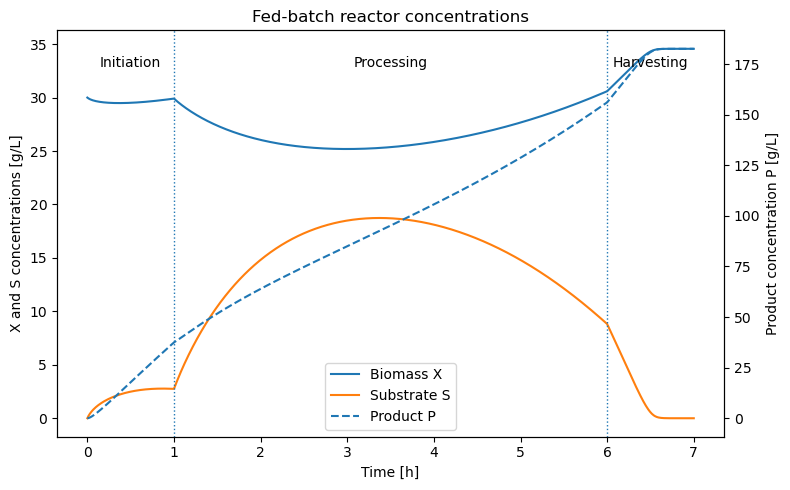

Final volume at t = 7 h: 1.050 L
Final biomass concentration X: 34.563 g/L
Final substrate concentration S: 0.000 g/L
Final product concentration P: 182.535 g/L


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
mu_max = 0.3        # h^{-1}
K_s = 0.8           # g glucose / L
K_I = 100           # g glucose / L
Y_XS = 0.45         # g cells / g glucose
Y_XP = 0.15         # g cells / g product
S0 = SP =80         # g glucose / L

# Initial conditions
V0 = 0.85           # L
X0 = 30             # g cells / L
S_init = 0          # negligible glucose
P_init = 0          # g product / L

NX0 = X0 * V0       # g cells
NS0 = S_init * V0   # g glucose
NP0 = P_init * V0   # g product

y0 = [NX0, NS0, NP0, V0]

# =========================================================
# Growth rate with substrate inhibition
# =========================================================

def mu_net(S):
    return mu_max * S / (K_s + S + S**2 / K_I)

# =========================================================
# ODE system
# y = [NX, NS, NP, V]
# =========================================================

def fed_batch_odes(t, y):
    NX, NS, NP, V = y
    
    X = NX / V
    S = NS / V
    P = NP / V
    
    mu = mu_net(S)
    
    # Operating mode
    if t <= 1:
        F_in = 0.2
        S_in = S0
        F_out = 0
        
    elif t <= 6:
        F_in = 0.5
        S_in = SP
        F_out = 0
        
    else:
        F_in = 0
        S_in = 0
        F_out = 2.5
    
    dNXdt = mu * X * V - F_out * X
    dNSdt = F_in * S_in - (mu * X * V) / Y_XS - F_out * S
    dNPdt = (mu * X * V) / Y_XP - F_out * P
    dVdt = F_in - F_out
    
    return [dNXdt, dNSdt, dNPdt, dVdt]

# =========================================================
# Numerical integration
# =========================================================

t_span = (0, 7)
t_eval = np.linspace(0, 7, 1000)

sol = solve_ivp(
    fed_batch_odes,
    t_span,
    y0,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-8,
    atol=1e-10
)

t = sol.t
NX, NS, NP, V = sol.y

X = NX / V
S = NS / V
P = NP / V

# =========================================================
# Plot
# =========================================================

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(t, X, label="Biomass X")
ax1.plot(t, S, label="Substrate S")
ax1.set_xlabel("Time [h]")
ax1.set_ylabel("X and S concentrations [g/L]")

ax2 = ax1.twinx()
ax2.plot(t, P, linestyle="--", label="Product P")
ax2.set_ylabel("Product concentration P [g/L]")

# Vertical lines for operating modes
ax1.axvline(1, linestyle=":", linewidth=1)
ax1.axvline(6, linestyle=":", linewidth=1)

ax1.text(0.5, max(X)*0.95, "Initiation", ha="center")
ax1.text(3.5, max(X)*0.95, "Processing", ha="center")
ax1.text(6.5, max(X)*0.95, "Harvesting", ha="center")

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title("Fed-batch reactor concentrations")
plt.tight_layout()
plt.show()

# =========================================================
# Final values
# =========================================================

print(f"Final volume at t = 7 h: {V[-1]:.3f} L")
print(f"Final biomass concentration X: {X[-1]:.3f} g/L")
print(f"Final substrate concentration S: {S[-1]:.3f} g/L")
print(f"Final product concentration P: {P[-1]:.3f} g/L")